# EDA - BIHAR-TAXI

Notebook d'analyse exploratoire dans l'esprit du projet BIHAR-DIABETES, adapté au dataset NYC Taxi Trip Duration.

In [44]:
import os
import sqlite3

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    %pip install seaborn
    import seaborn as sns

import sys
sys.path.insert(0, os.path.abspath('..'))
import common

sns.set_style('darkgrid')
sns.set(rc={'figure.figsize':(12,4)})
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42

In [45]:
DB_PATH = common.CONFIG['paths']['db_path']
DB_PATH

'/Users/auzoufrederic/MLOPS/BIHAR-TAXI/data/taxi.db'

In [46]:
with sqlite3.connect(DB_PATH) as con:
    train = pd.read_sql('SELECT * FROM train', con, parse_dates=['pickup_datetime'])
    test = pd.read_sql('SELECT * FROM test', con, parse_dates=['pickup_datetime'])


print('Train shape:', train.shape)
print('Test shape :', test.shape)

Train shape: (1021050, 9)
Test shape : (437594, 9)


In [47]:
train.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,844
1,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,1001
2,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,1048
3,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,784
4,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,732


In [48]:
train.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
vendor_id,1021050.0,NaN,NaN,NaN,1.535298,1.0,1.0,2.0,2.0,2.0,0.498753
pickup_datetime,1021050,NaN,NaN,NaN,2016-04-01 09:53:22.825644288,2016-01-01 00:00:17,2016-02-17 16:33:59.249999872,2016-04-01 16:06:20,2016-05-15 03:15:51.500000,2016-06-30 23:59:39,NaN
passenger_count,1021050.0,NaN,NaN,NaN,1.663364,0.0,1.0,1.0,2.0,9.0,1.312695
pickup_longitude,1021050.0,NaN,NaN,NaN,-73.973468,-121.933235,-73.991875,-73.98175,-73.967339,-61.335529,0.06454
pickup_latitude,1021050.0,NaN,NaN,NaN,40.750926,34.359695,40.737335,40.754105,40.768341,51.881084,0.033474
dropoff_longitude,1021050.0,NaN,NaN,NaN,-73.973393,-121.933205,-73.991318,-73.979752,-73.963028,-61.335529,0.064161
dropoff_latitude,1021050.0,NaN,NaN,NaN,40.751804,32.181141,40.735867,40.754528,40.769806,43.921028,0.035816
store_and_fwd_flag,1021050,2,N,1015403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_duration,1021050.0,NaN,NaN,NaN,961.719308,1.0,397.0,663.0,1075.0,3526282.0,5900.133069


In [49]:
missing = train.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

## Analyse de la cible

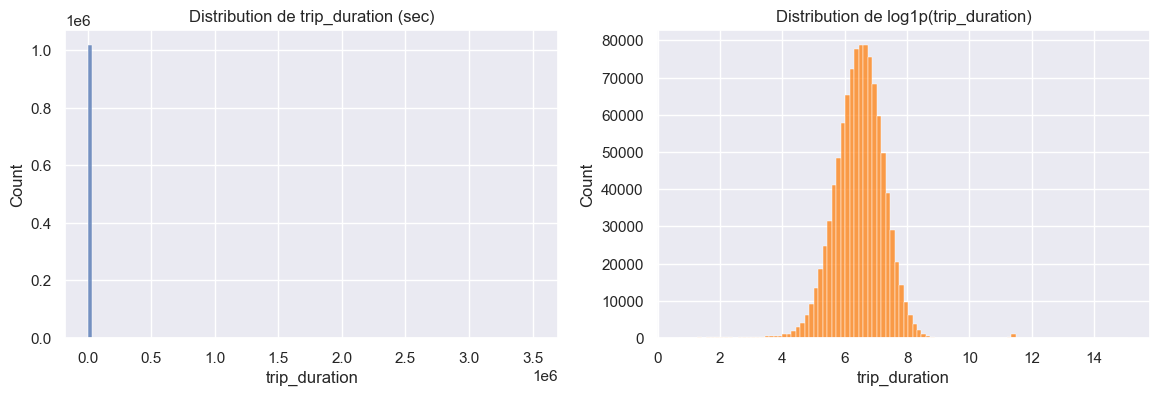

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train['trip_duration'], bins=100, ax=ax[0])
ax[0].set_title('Distribution de trip_duration (sec)')

sns.histplot(np.log1p(train['trip_duration']), bins=100, ax=ax[1], color='tab:orange')
ax[1].set_title('Distribution de log1p(trip_duration)')
plt.show()

## Features temporelles

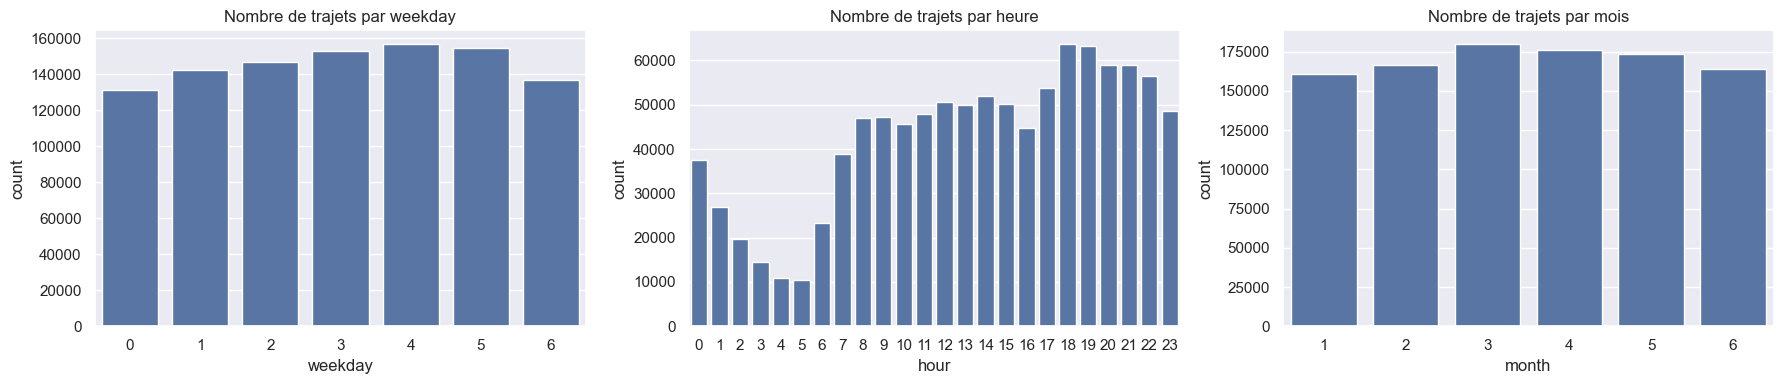

In [51]:
tmp = train.copy()
tmp['weekday'] = tmp['pickup_datetime'].dt.weekday
tmp['hour'] = tmp['pickup_datetime'].dt.hour
tmp['month'] = tmp['pickup_datetime'].dt.month

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x='weekday', data=tmp, ax=ax[0])
ax[0].set_title('Nombre de trajets par weekday')
sns.countplot(x='hour', data=tmp, ax=ax[1])
ax[1].set_title('Nombre de trajets par heure')
sns.countplot(x='month', data=tmp, ax=ax[2])
ax[2].set_title('Nombre de trajets par mois')
plt.tight_layout()
plt.show()

## Corrélations numériques

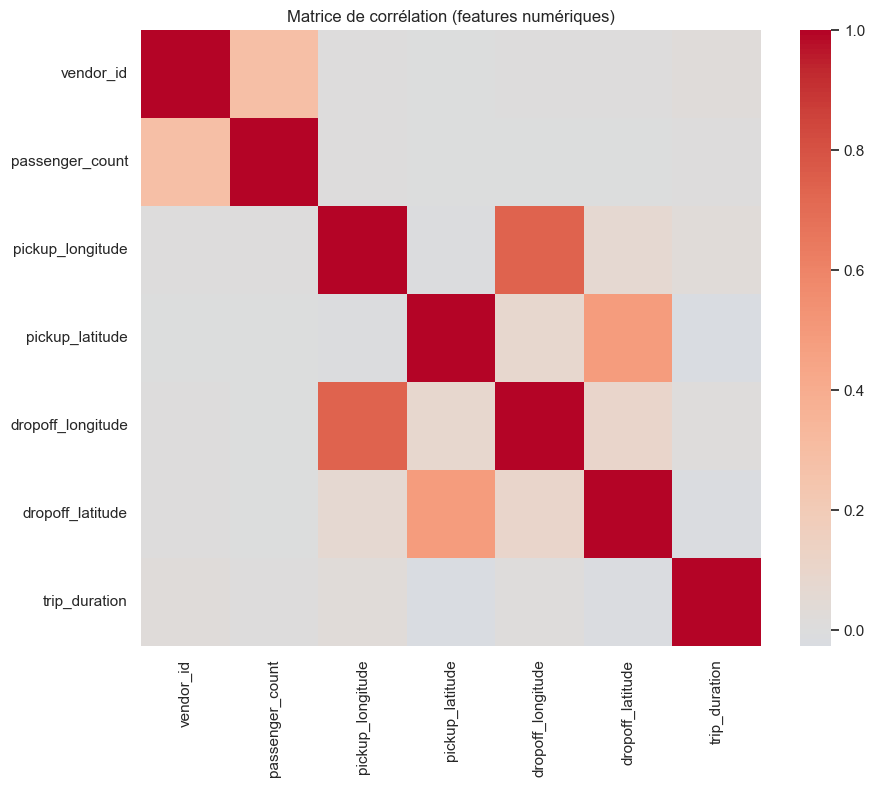

In [52]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation (features numériques)')
plt.show()

## Task 1. Import data

Read the data into `pd.DataFrame` objects, display dimensions and a few rows, check descriptive statistics, detect columns with unique values per row, drop unusable columns, verify `pickup_datetime`, then split the data into `train` and `test`.

In [53]:
with sqlite3.connect(DB_PATH) as con:
    train = pd.read_sql('SELECT * FROM train', con, parse_dates=['pickup_datetime'])
    test = pd.read_sql('SELECT * FROM test', con, parse_dates=['pickup_datetime'])

print('Train shape:', train.shape)
print('Test shape :', test.shape)

display(train.head())
display(train.sample(10, random_state=RANDOM_STATE))
display(train.describe().T)
display(train.describe(include='object').T)

for name, df in [('train', train), ('test', test)]:
    unique_cols = [col for col in df.columns if df[col].nunique(dropna=False) == len(df)]
    print(f'{name} unique columns: {unique_cols if unique_cols else "none"}')

train = train.drop(columns=['dropoff_datetime'], errors='ignore')
test = test.drop(columns=['dropoff_datetime'], errors='ignore')

train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'])

X_train = train.drop(columns=['trip_duration']).copy()
y_train = train['trip_duration'].copy()
X_test = test.drop(columns=['trip_duration']).copy()
y_test = test['trip_duration'].copy()

X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

display(X_train.head())
display(y_train.head())
display(X_train.dtypes)

Train shape: (1021050, 9)
Test shape : (437594, 9)


,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,844
1,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,1001
2,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,1048
3,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,784
4,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,732


,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
366417,2,2016-04-19 11:30:09,1,-73.989449,40.729885,-73.972351,40.753857,N,904
914052,1,2016-04-27 14:15:34,1,-74.007538,40.725700,-74.002602,40.715111,N,365
114951,2,2016-03-25 12:44:33,1,-73.998680,40.729759,-73.995453,40.721661,N,534
960544,2,2016-02-03 20:26:28,1,-73.975822,40.760159,-73.975357,40.745720,N,657
640641,1,2016-04-16 09:16:22,1,-73.953323,40.782700,-73.948395,40.774136,N,366
725667,2,2016-03-16 21:26:34,1,-73.972969,40.792801,-73.947662,40.796009,N,496
394037,2,2016-06-11 07:48:15,2,-73.971649,40.763432,-73.955223,40.785728,N,244
972212,2,2016-03-19 00:27:00,1,-73.990570,40.724659,-74.002129,40.752022,N,876
525142,2,2016-02-14 12:11:31,2,-73.941353,40.792042,-73.981255,40.768482,N,898
290903,2,2016-06-08 19:24:27,1,-73.996826,40.742096,-73.961830,40.768551,N,1396


,count,mean,min,25%,50%,75%,max,std
vendor_id,1021050.0,1.535298,1.0,1.0,2.0,2.0,2.0,0.498753
pickup_datetime,1021050,2016-04-01 09:53:22.825644288,2016-01-01 00:00:17,2016-02-17 16:33:59.249999872,2016-04-01 16:06:20,2016-05-15 03:15:51.500000,2016-06-30 23:59:39,NaN
passenger_count,1021050.0,1.663364,0.0,1.0,1.0,2.0,9.0,1.312695
pickup_longitude,1021050.0,-73.973468,-121.933235,-73.991875,-73.98175,-73.967339,-61.335529,0.06454
pickup_latitude,1021050.0,40.750926,34.359695,40.737335,40.754105,40.768341,51.881084,0.033474
dropoff_longitude,1021050.0,-73.973393,-121.933205,-73.991318,-73.979752,-73.963028,-61.335529,0.064161
dropoff_latitude,1021050.0,40.751804,32.181141,40.735867,40.754528,40.769806,43.921028,0.035816
trip_duration,1021050.0,961.719308,1.0,397.0,663.0,1075.0,3526282.0,5900.133069


,count,unique,top,freq
store_and_fwd_flag,1021050,2,N,1015403


train unique columns: none
test unique columns: none


,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N
1,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N
2,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N
3,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N
4,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N


0     844
1    1001
2    1048
3     784
4     732
Name: trip_duration, dtype: int64

vendor_id                      int64
pickup_datetime       datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
dtype: object

## Task 2. Target variable

### 2.1. Distribution

Check the distribution of the target variable values.

### 2.2. Evaluation metric

The evaluation metric is Root Mean Squared Logarithmic Error (RMSLE). It is preferred here because it measures relative errors and reduces the impact of very large trip durations, which makes the metric more stable for a skewed target.

### 2.3. Target transformation

Apply `np.log1p` to the target variable and display the histogram of the transformed target.

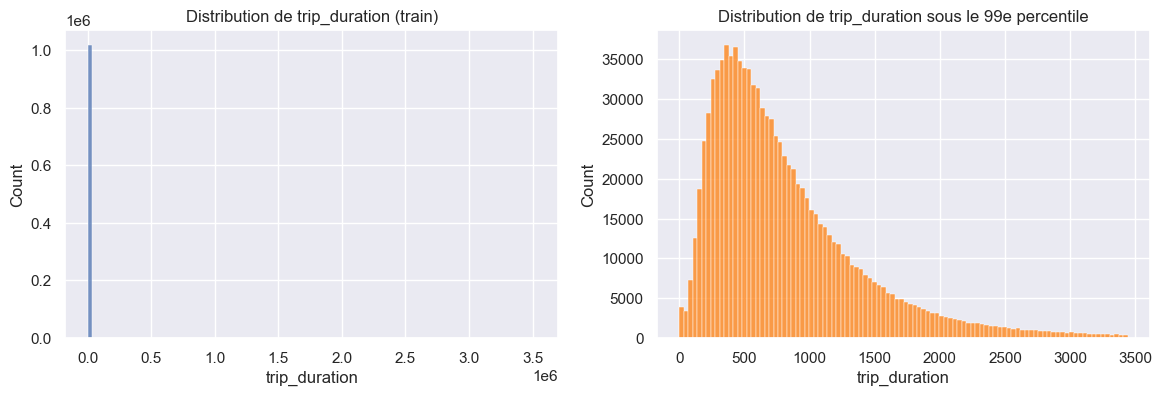

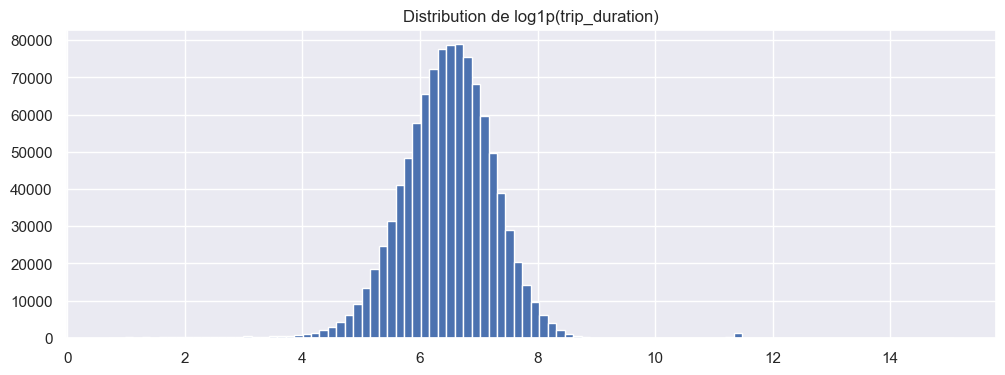

In [54]:
def transform_target(y):
    return np.log1p(y).rename('log_' + y.name)

y_train_log = transform_target(y_train)
y_test_log = transform_target(y_test)
y = pd.concat([y_train_log, y_test_log], ignore_index=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(y_train, bins=100, ax=ax[0])
ax[0].set_title('Distribution de trip_duration (train)')

sns.histplot(y_train[y_train < y_train.quantile(0.99)], bins=100, ax=ax[1], color='tab:orange')
ax[1].set_title('Distribution de trip_duration sous le 99e percentile')
plt.show()

y_train_log.hist(bins=100);
plt.title('Distribution de log1p(trip_duration)')
plt.show()

## Task 3. Baseline

Calcul de la meilleure constante sur la cible transformée.

In [55]:
y_baseline_log = y_train_log.mean()
y_baseline = np.expm1(y_baseline_log)

print(f'Baseline prediction (log): {y_baseline_log:.4f}')
print(f'Baseline prediction (sec): {y_baseline:.0f}')
print(f'RMSLE train: {rmsle(y_train, np.full(len(y_train), y_baseline)):.4f}')
print(f'RMSLE test : {rmsle(y_test, np.full(len(y_test), y_baseline)):.4f}')

Baseline prediction (log): 6.4671
Baseline prediction (sec): 643
RMSLE train: 0.7961
RMSLE test : 0.7950


## Task 4. `pickup_datetime` Analysis

### 4.1. Number of trips ~ date

Display the relationship between the number of trips and the date.

### 4.2. Number of trips ~ day of the week, hour of the day

Display two additional graphs: number of trips per weekday and number of journeys per hour of the day.

### 4.3. Number of trips ~ hour of the day for different months

Display on a single graph the dependency of the number of trips and the hour of the day for different months.

### 4.4. Trip duration ~ date, day of the week, hour of the day

Display the distribution of the average target value by the date, the day of the week, and the time of the day.

### 4.5. New features

Add new variables based on `pickup_datetime`: day of week, month, hour of day, abnormal period flags.

### 4.6. Ridge regression

Train Ridge regression using temporal features.

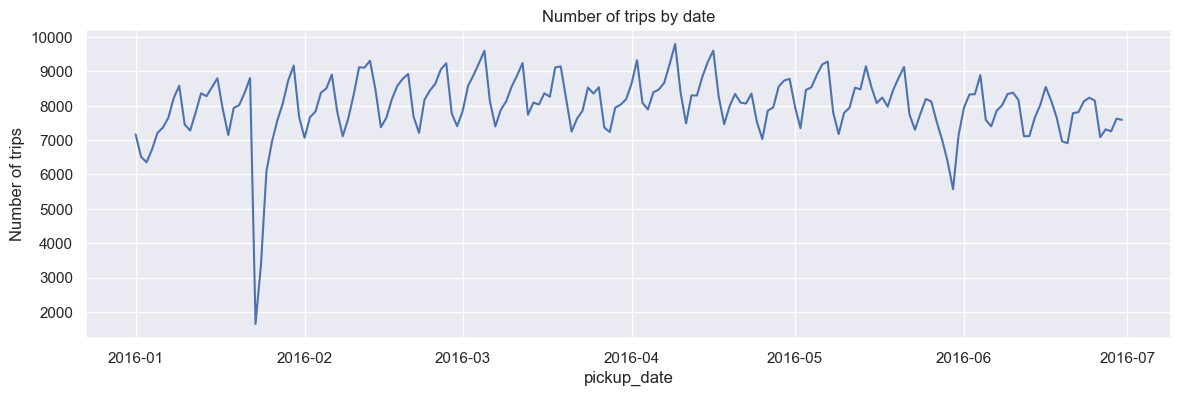

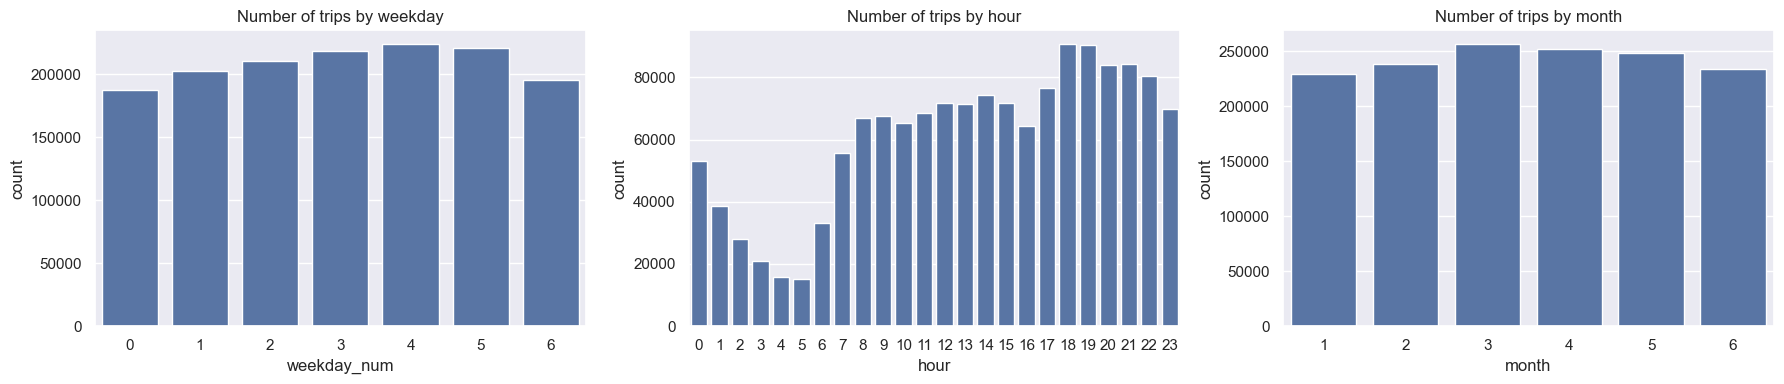

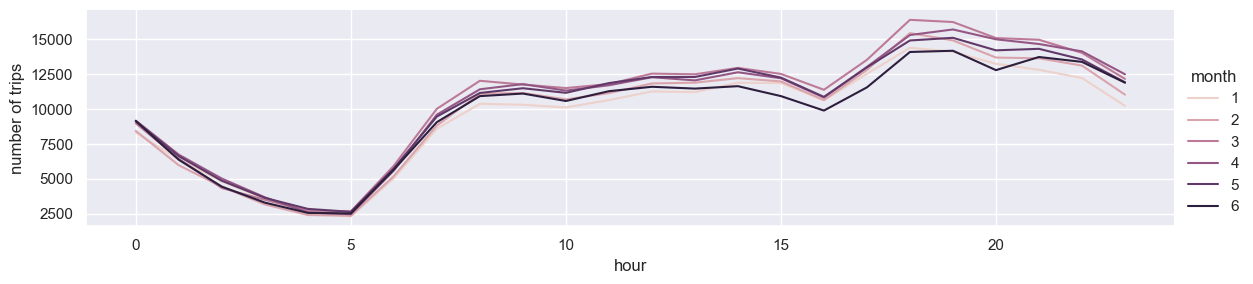

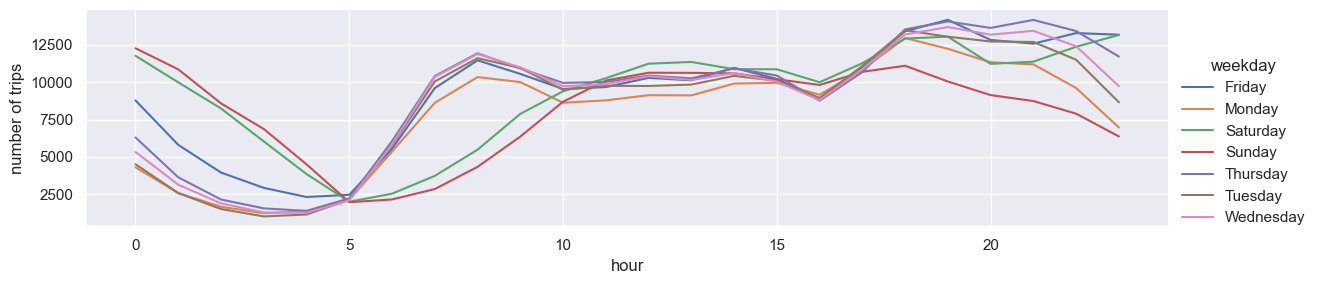

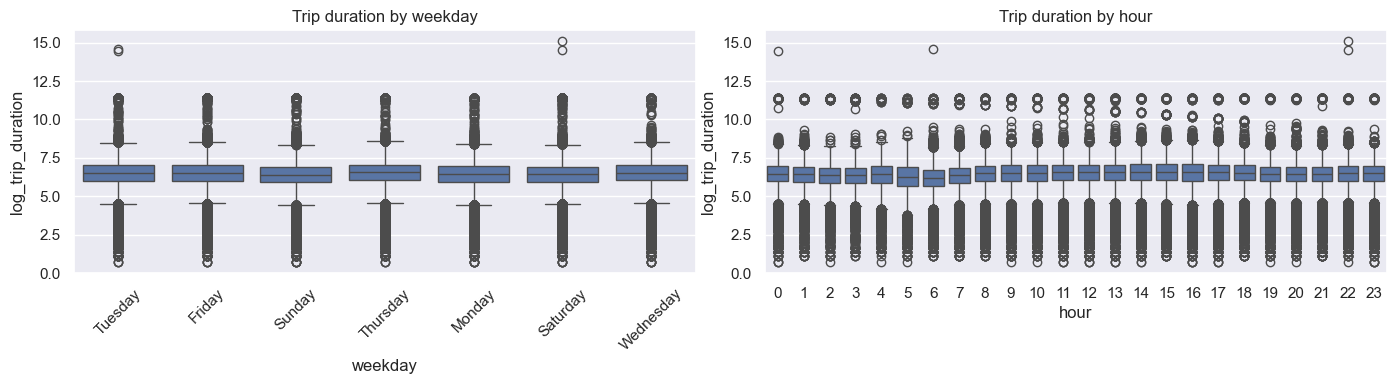

In [56]:
# Task 4.1: Number of trips by date
plt.figure(figsize=(14, 4))
X['pickup_date'] = X['pickup_datetime'].dt.date
sns.lineplot(data=X['pickup_date'].groupby(X['pickup_date']).count())
plt.title('Number of trips by date')
plt.ylabel('Number of trips')
plt.show()

# Task 4.2: Number of trips by weekday, hour, month
if 'weekday_num' not in X.columns:
    X['weekday_num'] = X['pickup_datetime'].dt.weekday
if 'hour' not in X.columns:
    X['hour'] = X['pickup_datetime'].dt.hour
if 'month' not in X.columns:
    X['month'] = X['pickup_datetime'].dt.month

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x='weekday_num', data=X, ax=ax[0])
ax[0].set_title('Number of trips by weekday')
sns.countplot(x='hour', data=X, ax=ax[1])
ax[1].set_title('Number of trips by hour')
sns.countplot(x='month', data=X, ax=ax[2])
ax[2].set_title('Number of trips by month')
plt.tight_layout()
plt.show()

# Task 4.3: Number of trips by hour for different months
dict_weekday = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekday = X['weekday_num'].map(dict_weekday).rename('weekday')
hourofday = X['hour'].rename('hour')
month = X['month'].rename('month')

data_plot = X.groupby([month, hourofday]).size().rename('number of trips').reset_index()
sns.relplot(data=data_plot, x='hour', y='number of trips', hue='month', kind='line', height=3, aspect=4)
plt.show()

data_plot = X.groupby([weekday, hourofday]).size().rename('number of trips').reset_index()
sns.relplot(data=data_plot, x='hour', y='number of trips', hue='weekday', kind='line', height=3, aspect=4)
plt.show()

# Task 4.4: Trip duration by weekday and hour
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=weekday, y=y, ax=ax[0])
ax[0].set_title('Trip duration by weekday')
ax[0].tick_params('x', labelrotation=45)
sns.boxplot(x=hourofday, y=y, ax=ax[1])
ax[1].set_title('Trip duration by hour')
plt.tight_layout()
plt.show()

## Task 6. Other Features Analysis

### 6.1. `vendor_id`, `passenger_count`, `store_and_fwd_flag`

Display unique values for each categorical feature and their distribution of the target.

### 6.2. Ridge regression

Train Ridge regression using temporal, geographical, and other categorical features.

Correlation between target and distance_haversine: 0.57
Correlation between target and log_distance_haversine: 0.75


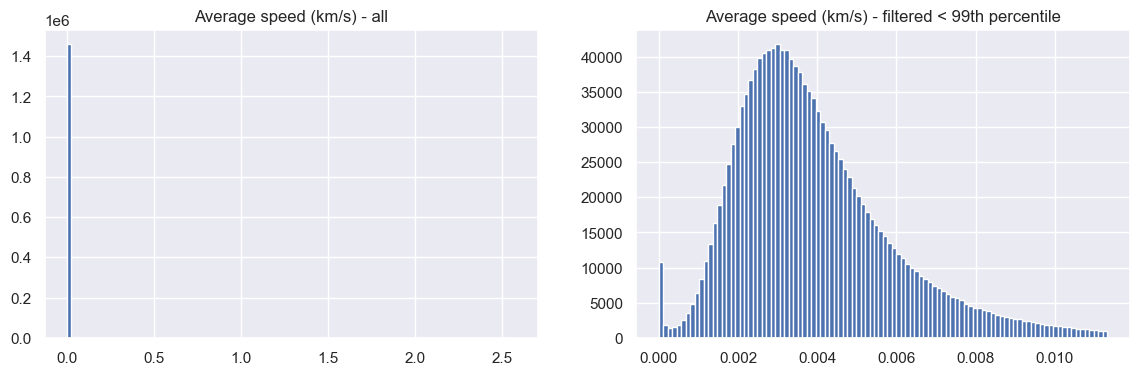

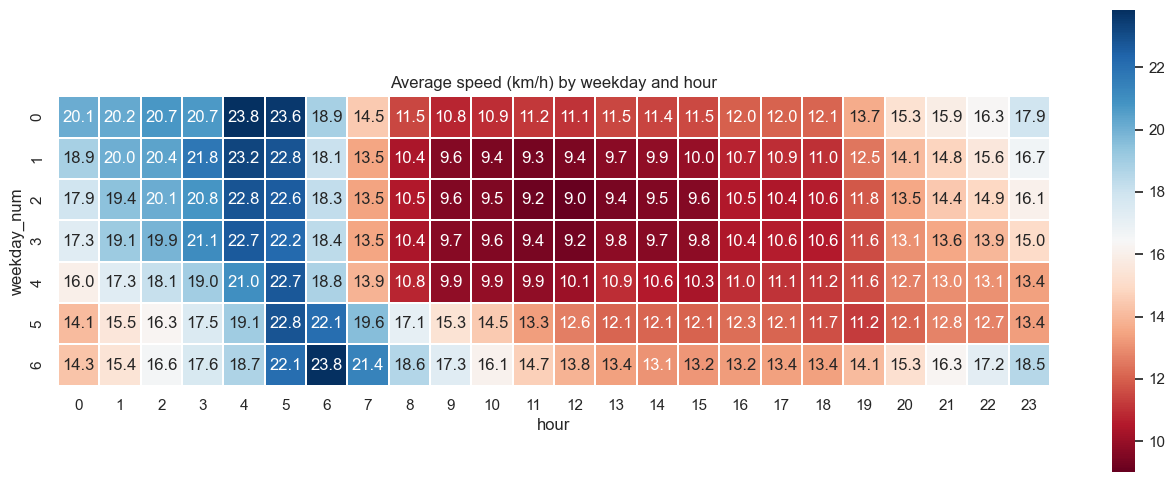

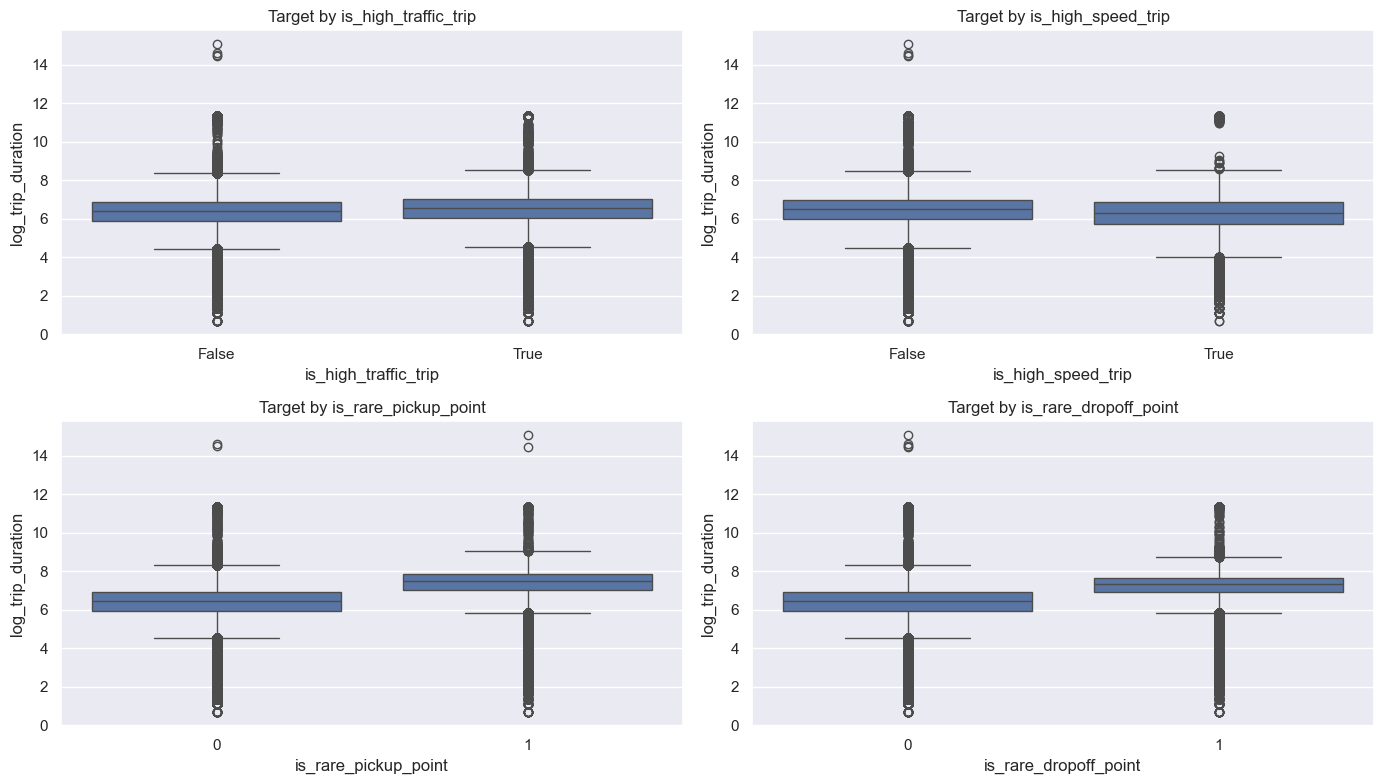

In [57]:
# Task 5.1-5.2: Distance analysis
from model.features import haversine_array

# Ensure temporal columns exist
if 'weekday_num' not in X.columns:
    X['weekday_num'] = X['pickup_datetime'].dt.weekday
if 'hour' not in X.columns:
    X['hour'] = X['pickup_datetime'].dt.hour
if 'month' not in X.columns:
    X['month'] = X['pickup_datetime'].dt.month

# Calculate distance and log-distance
distance_haversine = haversine_array(
    X['pickup_latitude'], X['pickup_longitude'],
    X['dropoff_latitude'], X['dropoff_longitude']
)
log_distance_haversine = np.log1p(distance_haversine)

# Check correlation with target
print(f'Correlation between target and distance_haversine: {np.corrcoef(x=distance_haversine, y=y)[0,1]:.2f}')
print(f'Correlation between target and log_distance_haversine: {np.corrcoef(x=log_distance_haversine, y=y)[0,1]:.2f}')

# Task 5.3: Speed estimation
avg_speed = distance_haversine / np.expm1(y)
avg_speed_clean = avg_speed[avg_speed < avg_speed.quantile(0.99)]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
avg_speed.hist(bins=100, ax=ax[0])
ax[0].set_title('Average speed (km/s) - all')
avg_speed_clean.hist(bins=100, ax=ax[1])
ax[1].set_title('Average speed (km/s) - filtered < 99th percentile')
plt.show()

# Speed heatmap by weekday and hour
data_plot = avg_speed.groupby([X['weekday_num'], X['hour']]).median().rename('avg_speed').reset_index()
data_plot = data_plot.pivot(index='weekday_num', columns='hour', values='avg_speed')
f, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(data_plot*3600, annot=True, fmt='.1f', linewidths=0.1, square=True, cmap='RdBu', ax=ax)
ax.set_title('Average speed (km/h) by weekday and hour')
plt.show()

# Task 5.4-5.5: Define high-traffic and high-speed trips (without speed feature)
X['is_high_traffic_trip'] = (
    ((X['hour'] >= 8) & (X['hour'] <= 19) & (X['weekday_num'] >= 0) & (X['weekday_num'] <= 4)) |
    ((X['hour'] >= 13) & (X['hour'] <= 20) & (X['weekday_num'] == 5))
)
X['is_high_speed_trip'] = (
    ((X['hour'] >= 2) & (X['hour'] <= 5) & (X['weekday_num'] >= 0) & (X['weekday_num'] <= 4)) |
    ((X['hour'] >= 4) & (X['hour'] <= 7) & (X['weekday_num'] == 5))
)

# Rare points detection
lat_cols = ['pickup_latitude', 'dropoff_latitude']
lon_cols = ['pickup_longitude', 'dropoff_longitude']
for lat_col, is_rare_col in [('pickup_latitude', 'is_rare_pickup_point'), ('dropoff_latitude', 'is_rare_dropoff_point')]:
    lon_col = 'pickup_longitude' if lat_col == 'pickup_latitude' else 'dropoff_longitude'
    lat_min, lat_max = X[lat_col].quantile(0.01), X[lat_col].quantile(0.995)
    lon_min, lon_max = X[lon_col].quantile(0.0), X[lon_col].quantile(0.95)
    X[is_rare_col] = ((X[lat_col] < lat_min) | (X[lat_col] > lat_max) |
                       (X[lon_col] < lon_min) | (X[lon_col] > lon_max)).astype(int)

# Plot new features
new_cat_features = ['is_high_traffic_trip', 'is_high_speed_trip', 'is_rare_pickup_point', 'is_rare_dropoff_point']
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
for idx, feat in enumerate(new_cat_features):
    row, col = idx // 2, idx % 2
    sns.boxplot(x=X[feat], y=y, ax=ax[row, col])
    ax[row, col].set_title(f'Target by {feat}')
plt.tight_layout()
plt.show()

## Task 5. Coordinates Analysis

### 5.1. Geographical visualization

Visualize starting and ending points on a map (folium).

### 5.2. Distance estimation

Calculate haversine distance between pickup and dropoff locations. Use log-transformed distance as a feature.

### 5.3. Speed estimation

Calculate average speed for each trip. Identify high-traffic and high-speed periods.

### 5.4. Outliers

Detect and analyze outlier locations (rare pickup/dropoff points).

### 5.5. Check new features

Display box plots showing the distribution of the target by new categorical features.

### 5.6. Ridge regression

Train Ridge regression using both temporal and geographical features.

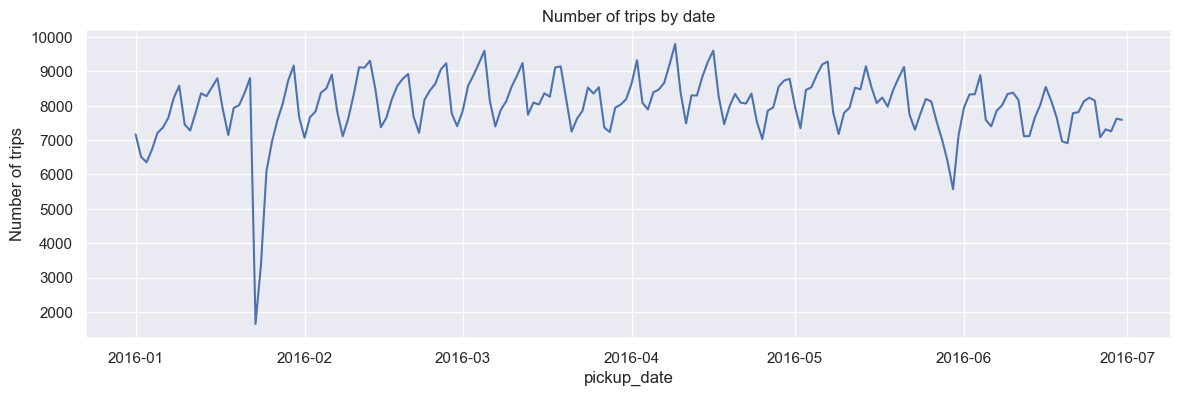

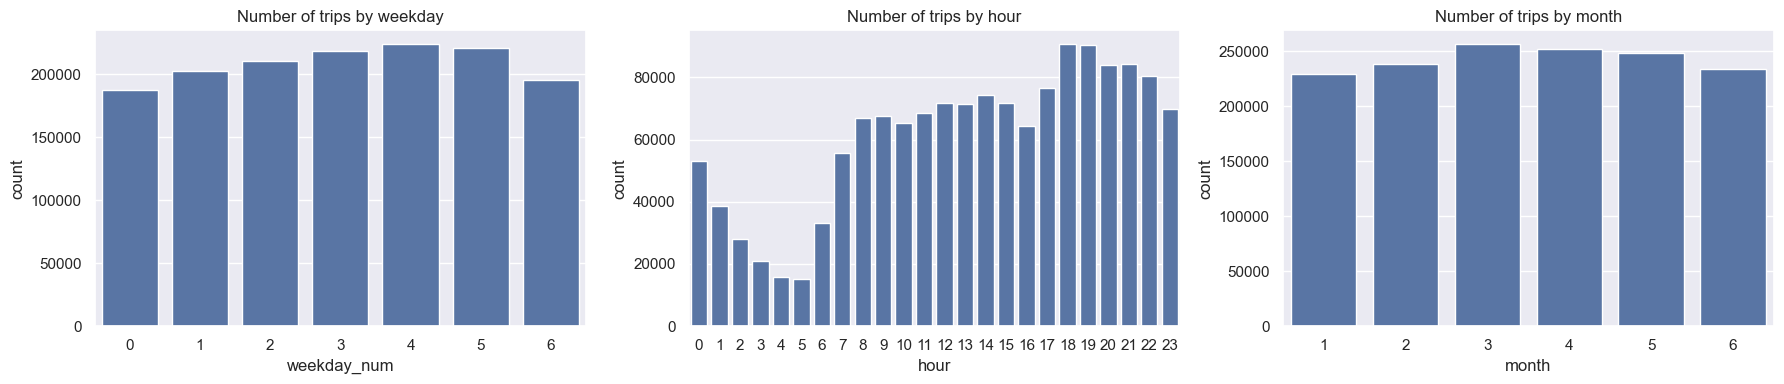

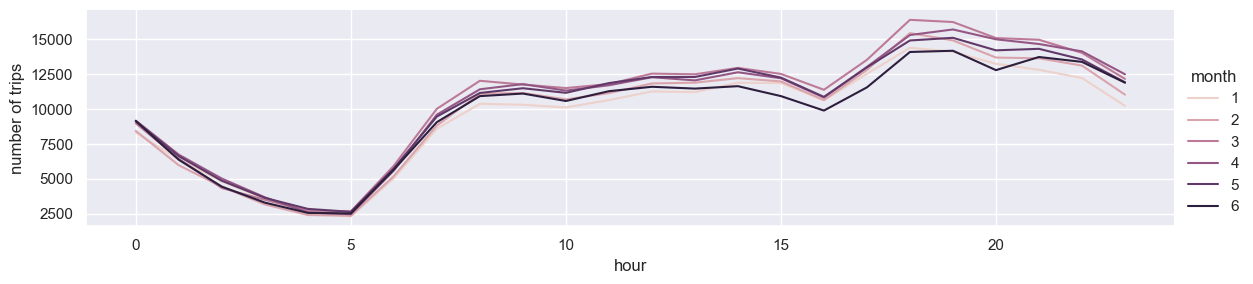

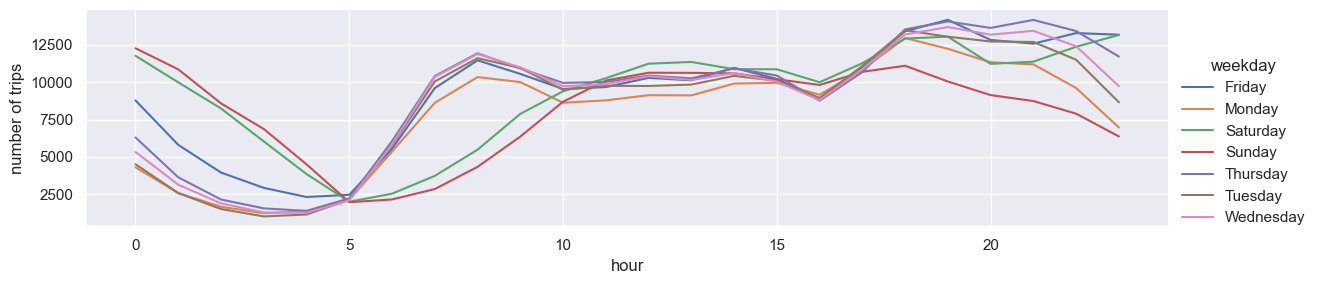

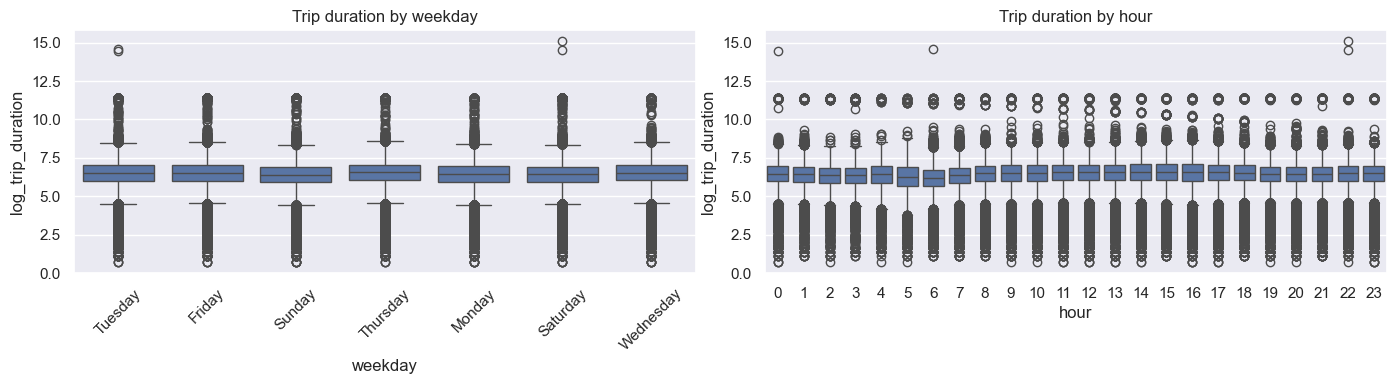

In [ ]:
V# Task 4.1: Number of trips by date
plt.figure(figsize=(14, 4))
X['pickup_date'] = X['pickup_datetime'].dt.date
sns.lineplot(data=X['pickup_date'].groupby(X['pickup_date']).count())
plt.title('Number of trips by date')
plt.ylabel('Number of trips')
plt.show()

# Task 4.2: Number of trips by weekday, hour, month
X['weekday_num'] = X['pickup_datetime'].dt.weekday
X['hour'] = X['pickup_datetime'].dt.hour
X['month'] = X['pickup_datetime'].dt.month

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x='weekday_num', data=X, ax=ax[0])
ax[0].set_title('Number of trips by weekday')
sns.countplot(x='hour', data=X, ax=ax[1])
ax[1].set_title('Number of trips by hour')
sns.countplot(x='month', data=X, ax=ax[2])
ax[2].set_title('Number of trips by month')
plt.tight_layout()
plt.show()

# Task 4.3: Number of trips by hour for different months
dict_weekday = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekday = X['weekday_num'].map(dict_weekday).rename('weekday')
hourofday = X['hour'].rename('hour')
month = X['month'].rename('month')

data_plot = X.groupby([month, hourofday]).size().rename('number of trips').reset_index()
sns.relplot(data=data_plot, x='hour', y='number of trips', hue='month', kind='line', height=3, aspect=4)
plt.show()

data_plot = X.groupby([weekday, hourofday]).size().rename('number of trips').reset_index()
sns.relplot(data=data_plot, x='hour', y='number of trips', hue='weekday', kind='line', height=3, aspect=4)
plt.show()

# Task 4.4: Trip duration by weekday and hour
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=weekday, y=y, ax=ax[0])
ax[0].set_title('Trip duration by weekday')
ax[0].tick_params('x', labelrotation=45)
sns.boxplot(x=hourofday, y=y, ax=ax[1])
ax[1].set_title('Trip duration by hour')
plt.tight_layout()
plt.show()

## Task 7. Nettoyage léger + Ridge vs Lasso

- suppression des outliers simples sur `trip_duration`
- comparaison Ridge / Lasso

In [59]:
from sklearn.linear_model import Lasso

q_low, q_high = y_train.quantile(0.01), y_train.quantile(0.99)
mask = (y_train >= q_low) & (y_train <= q_high)

X_train_clean = X_train[mask]
y_train_clean = y_train[mask]
y_train_clean_log = np.log1p(y_train_clean)

X_train_clean_fe = build_model_features(X_train_clean)

lasso = Pipeline([
    ('prep', preprocess),
    ('model', Lasso(alpha=0.01, max_iter=20000))
])

ridge.fit(X_train_clean_fe[num_features + cat_features], y_train_clean_log)
lasso.fit(X_train_clean_fe[num_features + cat_features], y_train_clean_log)

ridge_test_log = ridge.predict(X_test_fe[num_features + cat_features])
lasso_test_log = lasso.predict(X_test_fe[num_features + cat_features])

print(f'Ridge test RMSE log: {root_mean_squared_error(y_test_log, ridge_test_log):.4f}')
print(f'Lasso test RMSE log: {root_mean_squared_error(y_test_log, lasso_test_log):.4f}')

Ridge test RMSE log: 0.4948
Lasso test RMSE log: 0.5012


## Task 8. Using other algorithms

Test rapide de modèles arbres/ensembles sur les mêmes features.

In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Encodage one-hot direct pour modèles arbres
X_train_model = pd.get_dummies(X_train_fe[num_features + cat_features], columns=cat_features, drop_first=False)
X_test_model = pd.get_dummies(X_test_fe[num_features + cat_features], columns=cat_features, drop_first=False)
X_test_model = X_test_model.reindex(columns=X_train_model.columns, fill_value=0)

models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=12, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=16, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_model, y_train_log)
    pred = model.predict(X_test_model)
    score = root_mean_squared_error(y_test_log, pred)
    results.append({'model': name, 'rmse_log_test': score})

results_df = pd.DataFrame(results).sort_values('rmse_log_test')
results_df

,model,rmse_log_test
1,RandomForest,0.462805
2,GradientBoosting,0.463833
0,DecisionTree,0.469236


In [61]:
summary = pd.DataFrame([
    {'model': 'Baseline constant', 'rmse_log_test': rmsle(y_test, np.full(len(y_test), y_baseline))},
    {'model': 'Ridge', 'rmse_log_test': root_mean_squared_error(y_test_log, ridge_test_log)},
    {'model': 'Lasso', 'rmse_log_test': root_mean_squared_error(y_test_log, lasso_test_log)}
])

if 'results_df' in globals():
    summary = pd.concat([summary, results_df], ignore_index=True)

summary.sort_values('rmse_log_test')

,model,rmse_log_test
3,RandomForest,0.462805
4,GradientBoosting,0.463833
5,DecisionTree,0.469236
1,Ridge,0.494780
2,Lasso,0.501159
0,Baseline constant,0.795027
